In this project, the Telco Customer Churn dataset is analyzed to explore patterns and relationships between customer characteristics and churn behavior. Exploratory Data Analysis (EDA) is performed to understand data distributions and feature relationships. The dataset is then preprocessed to prepare it for machine learning modeling. Multiple machine learning models are trained to predict customer churn, and model performance is evaluated and compared to determine the best performing approach.

# Telco Customer Churn Prediction

## Objective

The objective of this project is to build a machine learning model that predicts whether a telecom customer is likely to churn based on provided features.

By identifying high-risk customers in advance, the model aims to help the business improve customer retention strategies and reduce revenue loss.

### Understanding The Data (EDA)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('Telco Customer Churn Rate.csv')

In [ ]:
df.head()

In [ ]:
df.shape

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
cat_cols = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
        'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod']

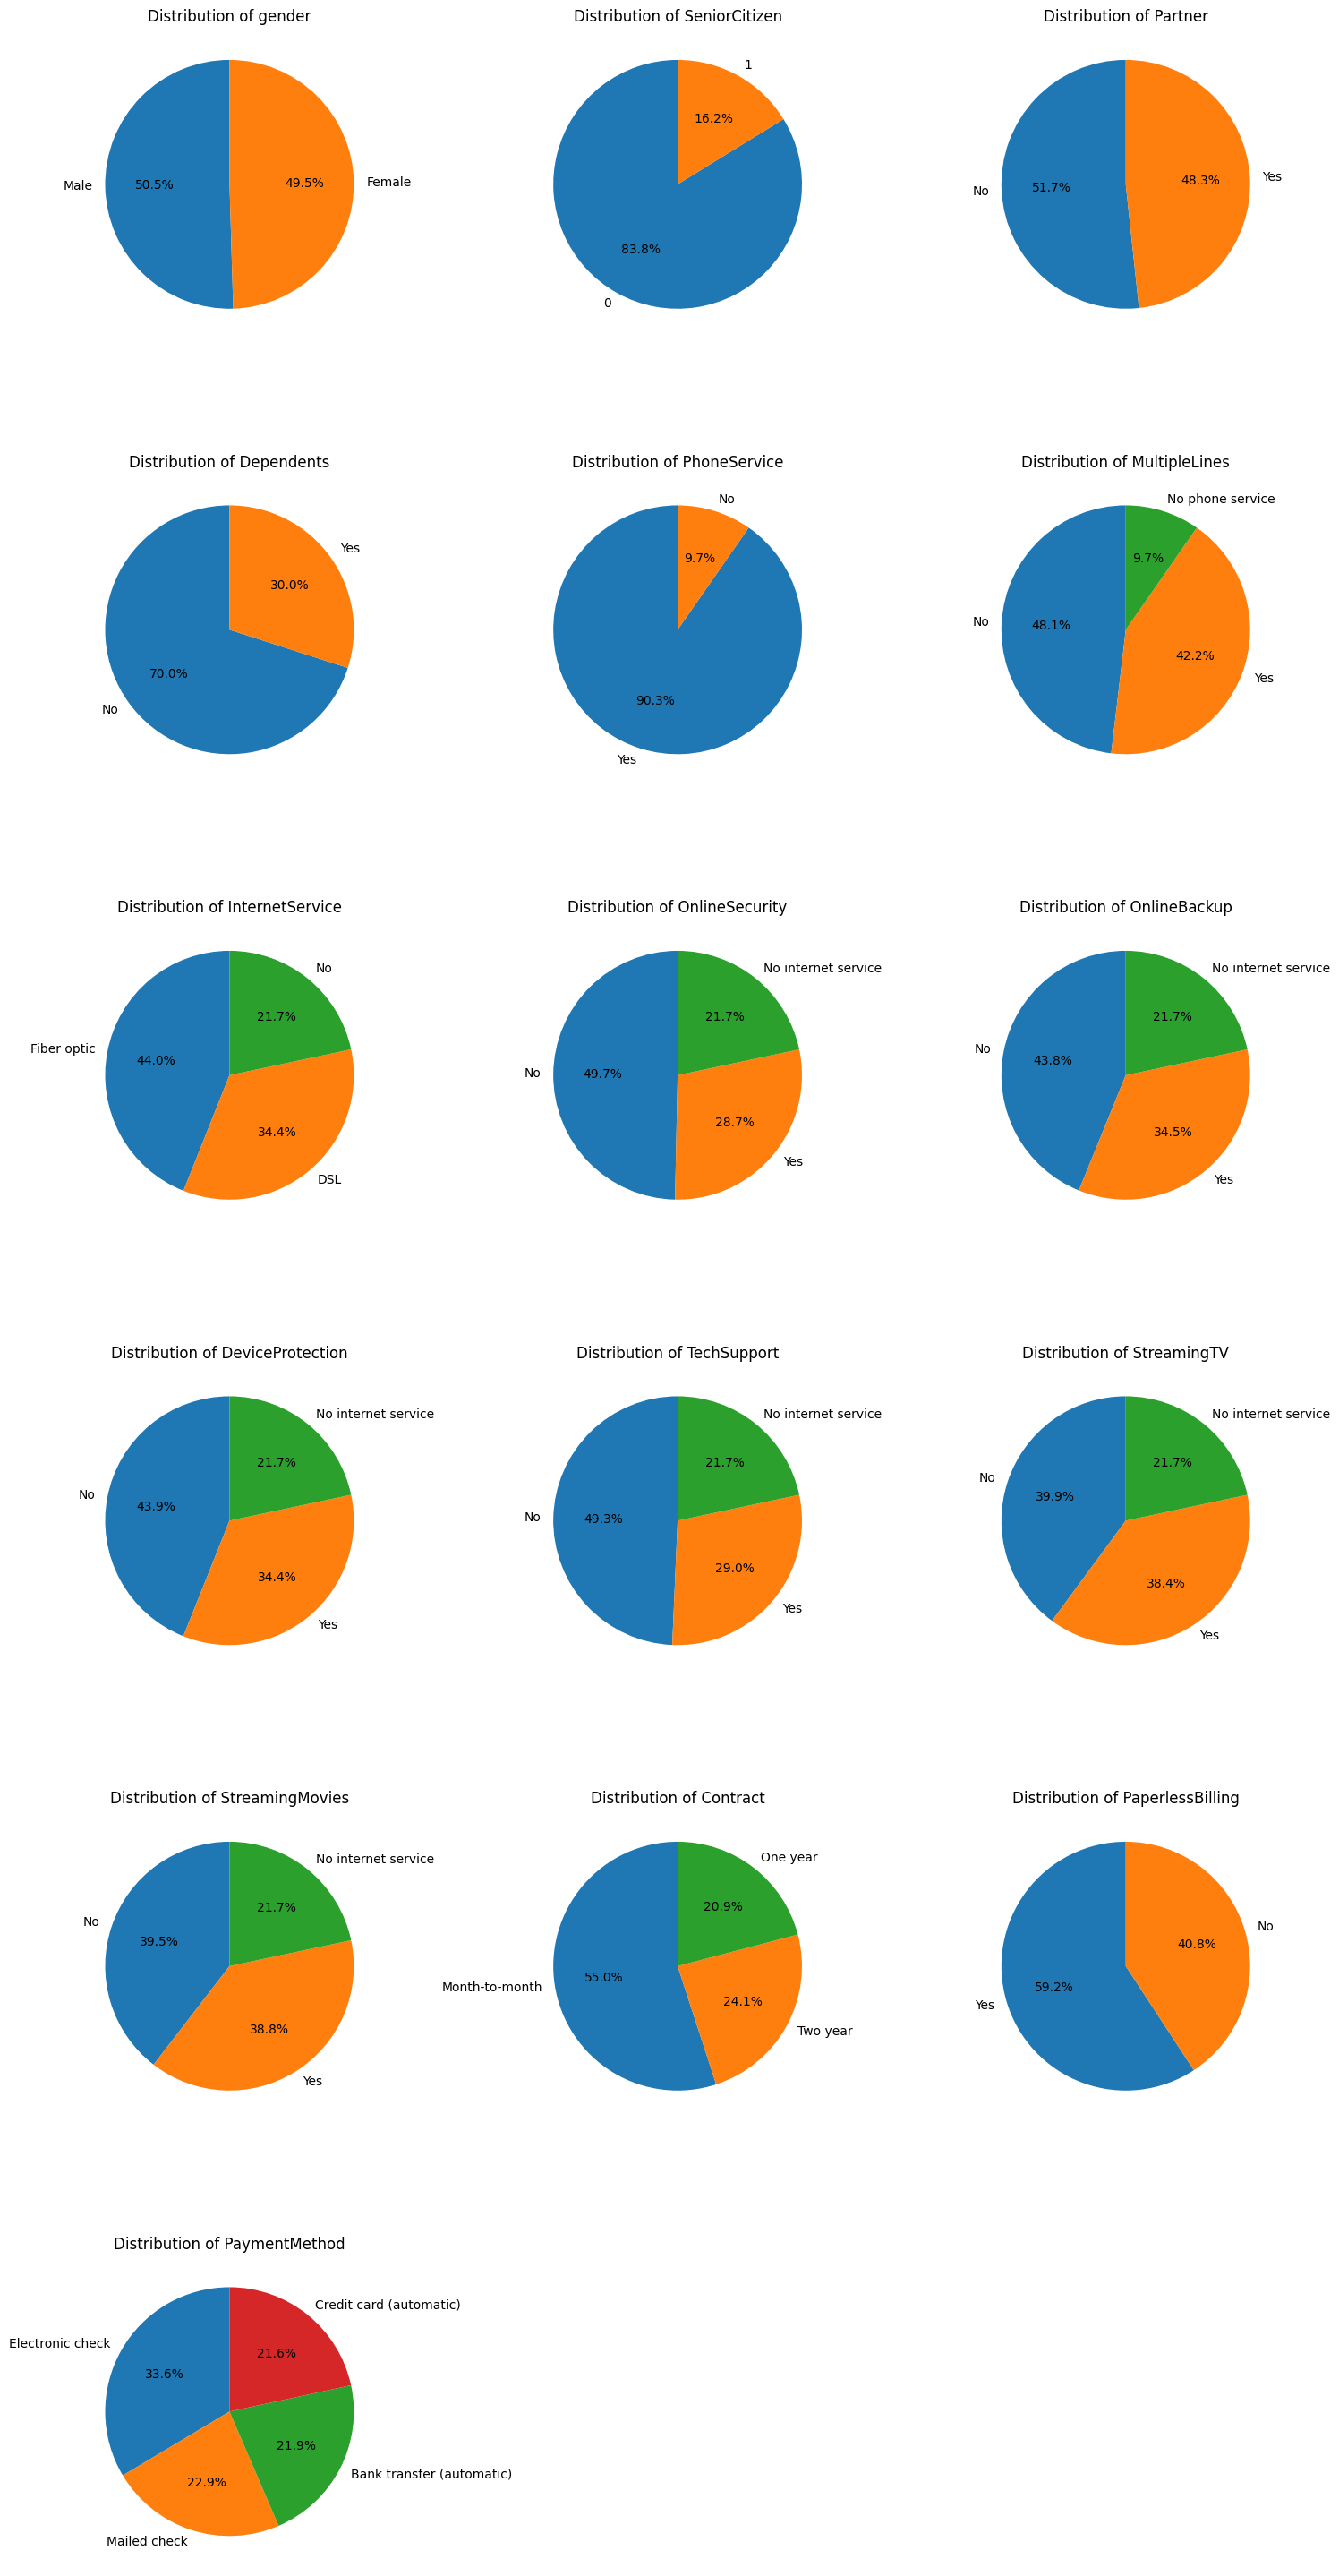

In [52]:
n = len(cat_cols)
n_cols = 3  
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(
     kind="pie",
        autopct="%1.1f%%",
        startangle=90,
        ax=axes[i]
    )
        
    axes[i].set_ylabel("")
    axes[i].set_title(f"Distribution of {col}")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

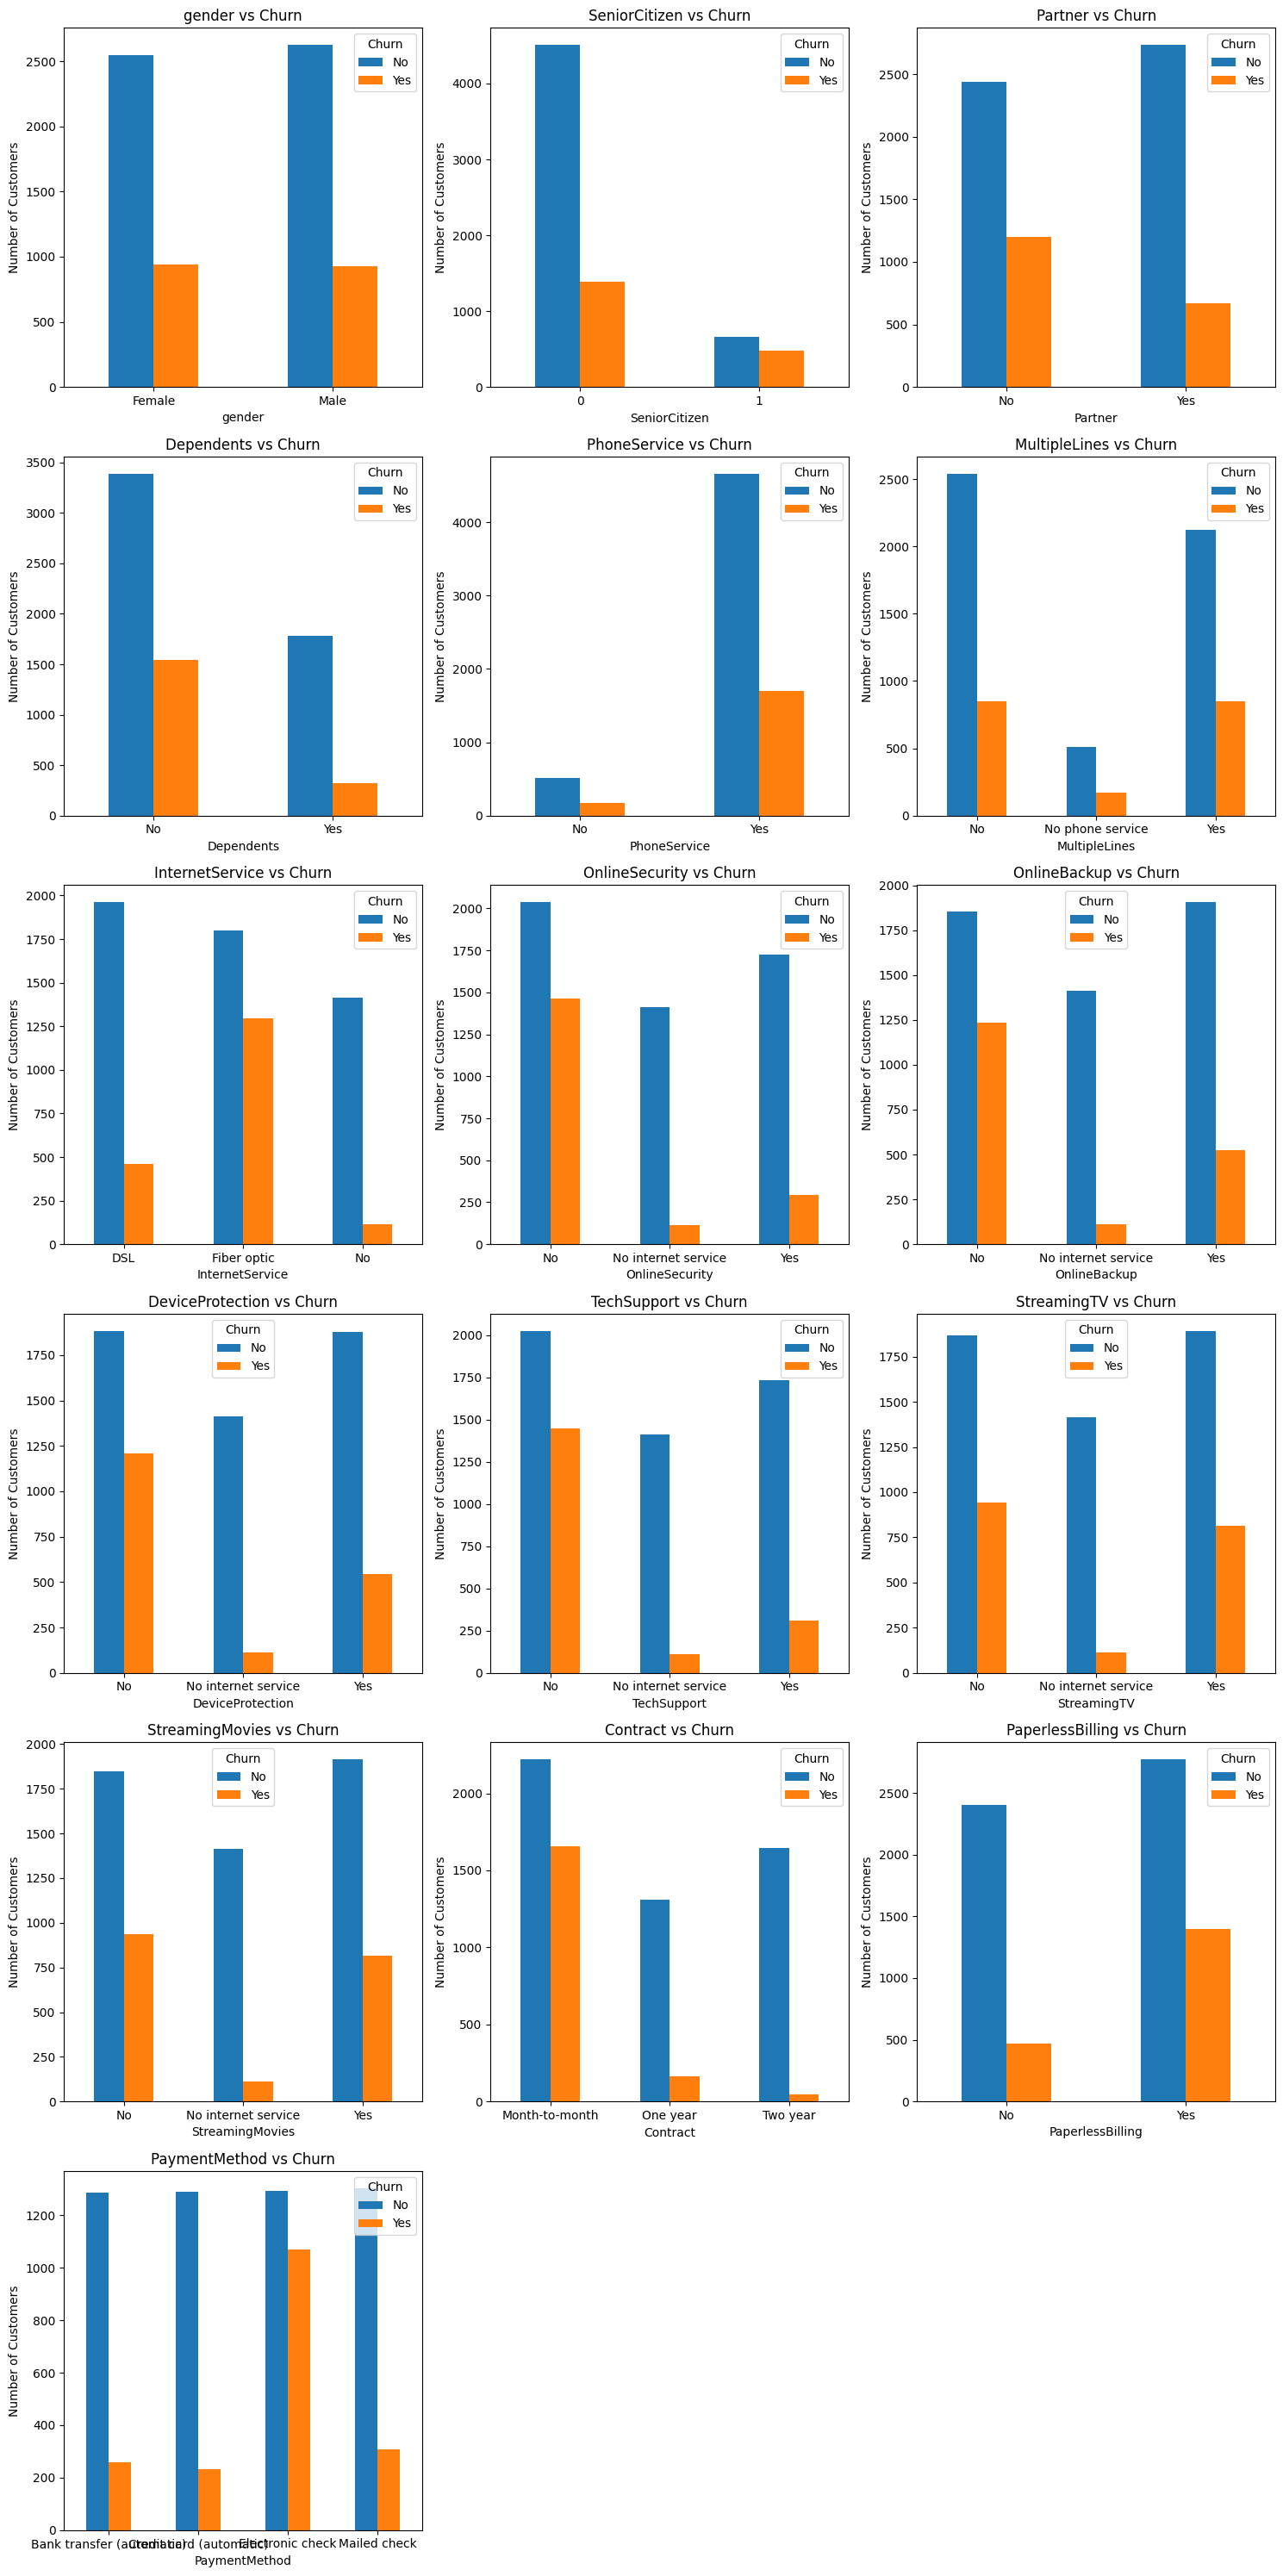

In [53]:
n = len(cat_cols)
n_cols = 3
n_rows = math.ceil(n / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    df.groupby([col, "Churn"]).size().unstack().plot(
        kind="bar",
        ax=axes[i]
    )
       
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Number of Customers")
    axes[i].set_title(f"{col} vs Churn")
    axes[i].tick_params(axis='x', rotation=0)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

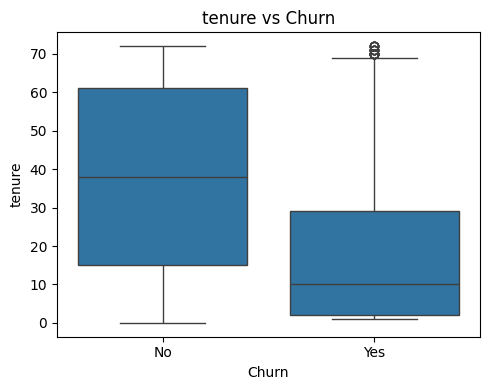

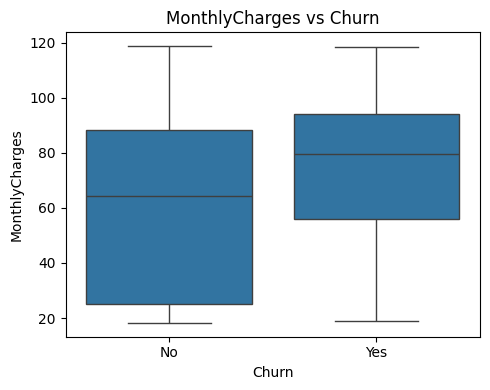

In [54]:
num_cols = ["tenure", "MonthlyCharges"]

for col in num_cols:
    plt.figure(figsize=(5, 4))
    
    sns.boxplot(x="Churn", y=col, data=df)
    
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.title(f"{col} vs Churn")
    
    plt.tight_layout()
    plt.show()

### Findings
Columns such as gender, PhoneService, MultipleLines, and Streaming services show little to no impact on churn, while factors like contract type, tenure, monthly charges, and support/security services have a strong influence.

### Data Preprocessing

#### Train Test Split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X = df.drop(columns=['customerID', 'Churn', 'TotalCharges'])
Y = df['Churn']

In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

#### Encoding

In [ ]:
categorical = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'PaperlessBilling', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'PaymentMethod', 'Contract']

numerical = ['MonthlyCharges', 'tenure']

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

In [ ]:
le = LabelEncoder()

Y_train = le.fit_transform(Y_train)
Y_test = le.transform(Y_test)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical),
        ("cat", OneHotEncoder(drop="first"), categorical)
    ], remainder="passthrough"
)

In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


### Model Implementation And Evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

#### 1. Logistic Regression

In [ ]:
model = LogisticRegression(max_iter=1000)

In [ ]:
model.fit(X_train_processed, Y_train)


In [ ]:
y_pred_log = model.predict(X_test_processed)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(Y_test, y_pred_log)
print("Accuracy:", accuracy)


In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(Y_test, y_pred_log)
print(cm)


#### 2. XG Boost

In [ ]:
xgb = XGBClassifier()
xgb.fit(X_train_processed, Y_train)

In [ ]:
y_pred_XG = xgb.predict(X_test_processed)

In [ ]:
print("Accuracy:", accuracy_score(Y_test, y_pred_XG))
print(confusion_matrix(Y_test, y_pred_XG))

#### 3. SVM

In [ ]:
from sklearn.svm import SVC
svm = SVC()
svm.fit(X_train_processed, Y_train)
y_pred_svm = svm.predict(X_test_processed)

In [ ]:
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print(confusion_matrix(Y_test, y_pred_svm))

Among the tested models, Logistic Regression performed the best with an accuracy of 0.82, followed by SVM with 0.81, while XGBoost achieved 0.79.